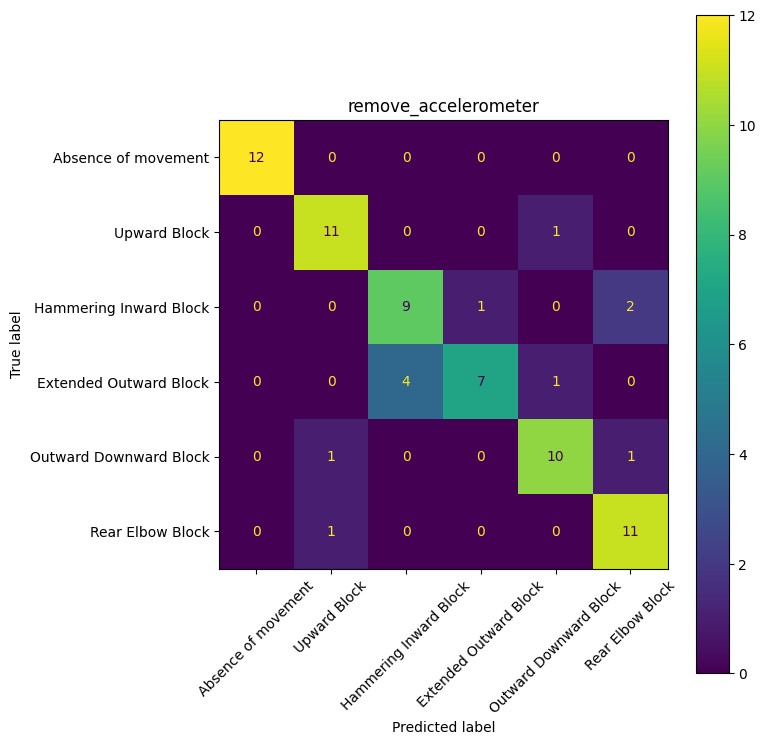

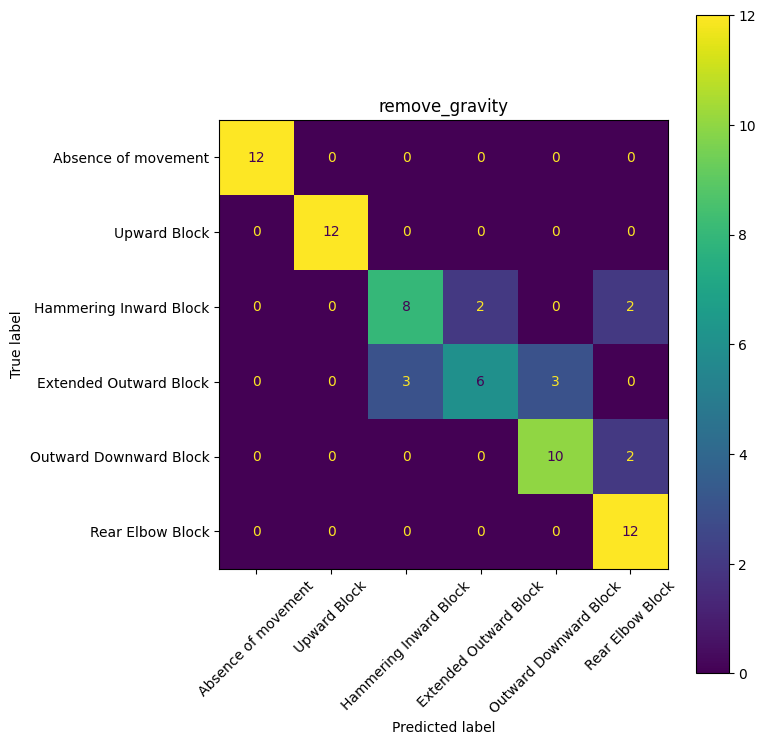

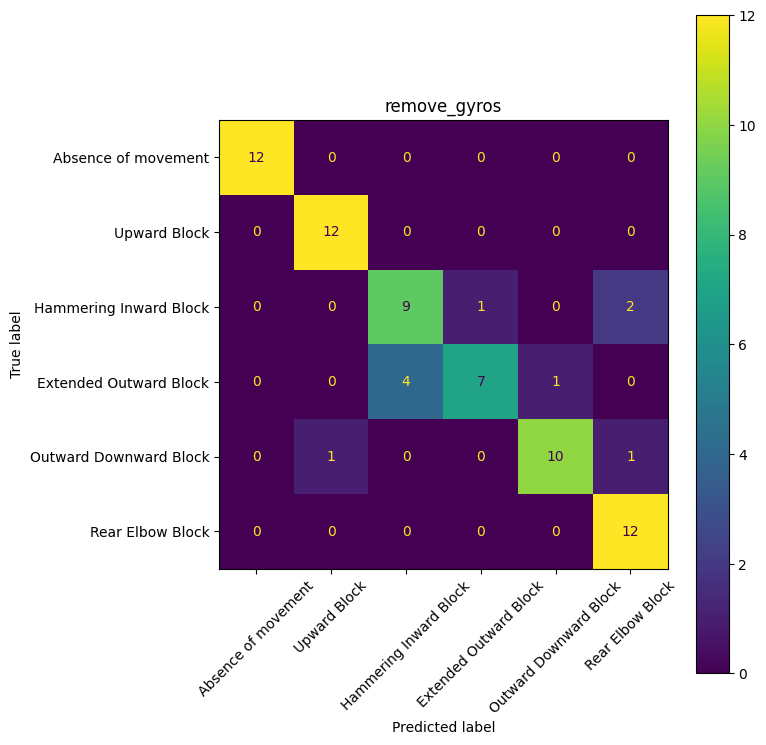

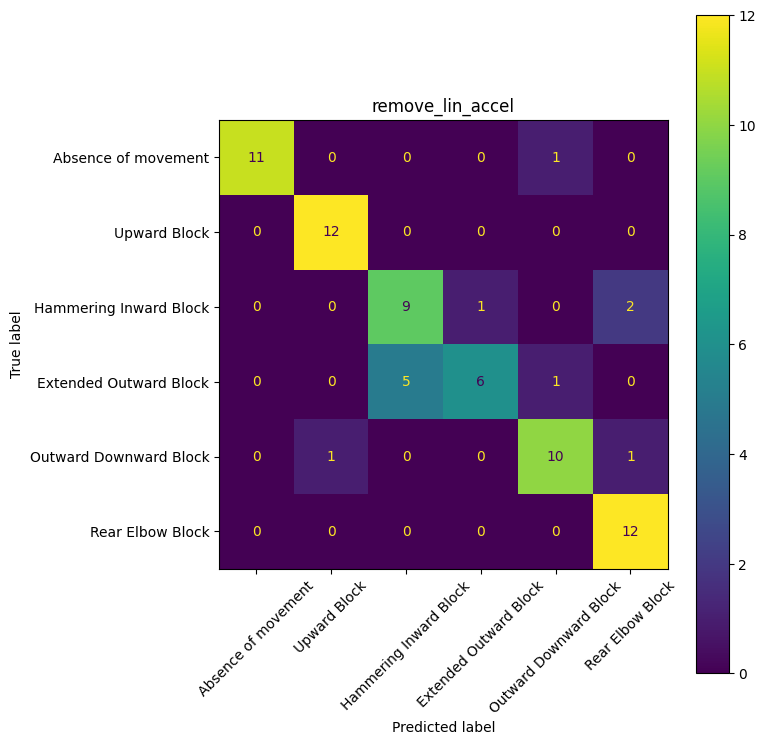

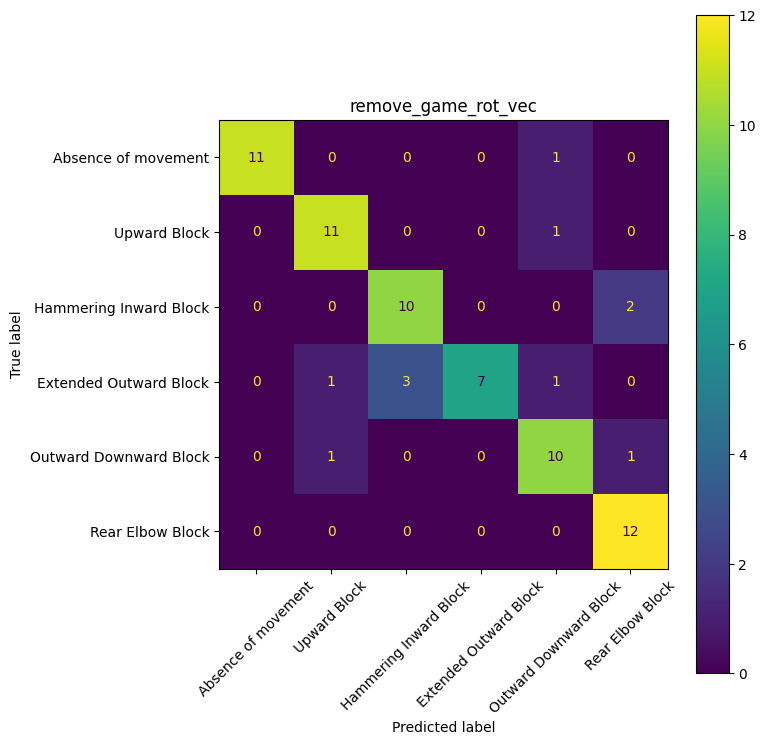

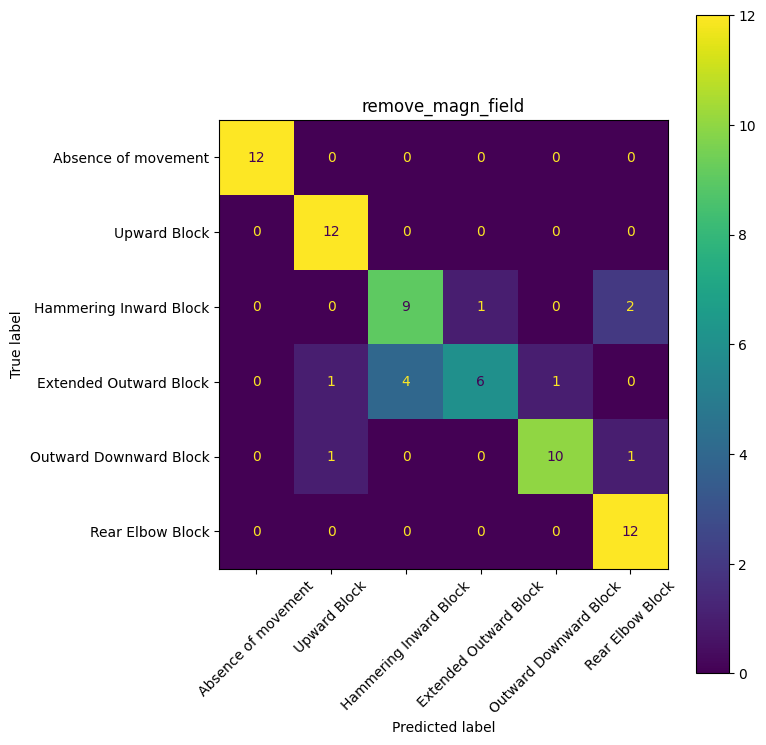

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


MOVEMENT_NAMES = [
    "Absence of movement",
    "Upward Block",
    "Hammering Inward Block",
    "Extended Outward Block",
    "Outward Downward Block",
    "Rear Elbow Block"
]




predictions_df = pd.read_csv(
    "../experimental_results/task_1_1/task_1_1_predictions.csv"
)


signal_experiments = [
    "remove_accelerometer",
    "remove_gravity",
    "remove_gyros",
    "remove_lin_accel",
    "remove_game_rot_vec",
    "remove_magn_field"
]

for experiment in signal_experiments:

    experiment_df = predictions_df[predictions_df["experiment"] == experiment]

    cm = confusion_matrix(
        experiment_df["true_label"],
        experiment_df["predicted_label"],
        labels=range(6)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=MOVEMENT_NAMES
    )

    fig, ax = plt.subplots(figsize=(8, 8))

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d"
    )

    ax.set_title(experiment)

    plt.tight_layout()

    plt.show()